In [38]:
import yfinance as yf
import pandas as pd
import numpy as np
import mplfinance as mpf
from datetime import datetime, timedelta

In [39]:
# data = yf.download("QUESS.BO", start= '2022-03-31', end= '2024-09-02', interval= '15m')
data = yf.download("QUESS.BO", period = '1mo', interval= '15m')
data.shape

[*********************100%***********************]  1 of 1 completed


(519, 6)

In [40]:
import pandas_ta as ta

In [41]:
data['max_5'] = data['Close'].rolling(window=5).max()
data

,Open,High,Low,Close,Adj Close,Volume,max_5
Datetime,,,,,,,
2024-08-05 09:15:00,661.500000,678.450012,661.049988,667.599976,667.599976,2544,NaN
2024-08-05 09:30:00,666.599976,675.599976,661.700012,671.900024,671.900024,698,NaN
2024-08-05 09:45:00,671.299988,679.200012,669.099976,678.500000,678.500000,425,NaN
2024-08-05 10:00:00,678.549988,679.099976,673.000000,675.400024,675.400024,442,NaN
2024-08-05 10:15:00,677.500000,677.500000,672.700012,672.700012,672.700012,137,678.500000
...,...,...,...,...,...,...,...
2024-09-03 14:15:00,822.849976,824.950012,818.900024,823.599976,823.599976,1933,826.900024
2024-09-03 14:30:00,822.099976,829.900024,821.049988,829.900024,829.900024,3414,829.900024
2024-09-03 14:45:00,830.000000,830.000000,823.650024,825.549988,825.549988,1538,829.900024


In [42]:
# 2. Calculate the 6 days ago Max(120, latest Close)
data['max_120_6_days_ago'] = data['Close'].shift(6).rolling(window=120).max()
data.tail()

,Open,High,Low,Close,Adj Close,Volume,max_5,max_120_6_days_ago
Datetime,,,,,,,,
2024-08-05 09:15:00,661.500000,678.450012,661.049988,667.599976,667.599976,2544,NaN,NaN
2024-08-05 09:30:00,666.599976,675.599976,661.700012,671.900024,671.900024,698,NaN,NaN
2024-08-05 09:45:00,671.299988,679.200012,669.099976,678.500000,678.500000,425,NaN,NaN
2024-08-05 10:00:00,678.549988,679.099976,673.000000,675.400024,675.400024,442,NaN,NaN
2024-08-05 10:15:00,677.500000,677.500000,672.700012,672.700012,672.700012,137,678.500000,NaN
...,...,...,...,...,...,...,...,...
2024-09-03 14:15:00,822.849976,824.950012,818.900024,823.599976,823.599976,1933,826.900024,820.099976
2024-09-03 14:30:00,822.099976,829.900024,821.049988,829.900024,829.900024,3414,829.900024,820.099976
2024-09-03 14:45:00,830.000000,830.000000,823.650024,825.549988,825.549988,1538,829.900024,820.099976


In [48]:
data['num'] = [i for i in range(len(data))]

In [53]:
data['moving_avg_126'] = data['close'].rolling(window = 126).max()

In [57]:
data['cond1'] = np.where(data['max_5'] > (data['max_120_6_days_ago']),1,0)

In [59]:
data['sma_vol'] = ta.sma(data['volume'], length=5)

In [61]:
data['cond2'] = np.where(data['volume'] > (data['sma_vol']),1,0)

In [65]:
data['cond3'] = np.where(data['close'] > (data['close'].shift(1)),1,0)

In [67]:
data['Final_condi'] = np.where((data['cond1'] == 1) &
                               (data['cond2'] == 1) &
                               (data['cond3'] == 1), 1, 0)

In [68]:
data.to_csv('demo1')

In [70]:
buy_signal = data[data['Final_condi'] == 1]

In [71]:
buy_signal

,open,high,low,close,adj_close,volume,max_5,max_120_6_days_ago,num,moving_avg_126,cond1,sma_vol,cond2,cond3,Final_condi
datetime,,,,,,,,,,,,,,,
2024-08-12 10:15:00,709.299988,716.849976,709.299988,713.849976,713.849976,5267,719.450012,711.599976,128,719.450012,1,3631.4,1,1,1
2024-08-21 09:15:00,726.299988,738.599976,723.900024,735.150024,735.150024,10276,735.150024,719.000000,272,735.150024,1,2788.2,1,1,1
2024-08-26 09:45:00,741.549988,749.950012,741.549988,749.900024,749.900024,3938,749.900024,735.150024,347,749.900024,1,3187.4,1,1,1
2024-08-26 10:00:00,751.000000,757.000000,745.000000,757.000000,757.000000,12581,757.000000,735.150024,348,757.000000,1,5632.6,1,1,1
2024-08-26 10:30:00,755.950012,765.000000,755.000000,764.349976,764.349976,11783,764.349976,735.150024,350,764.349976,1,7182.2,1,1,1
2024-08-26 10:45:00,764.349976,774.799988,764.000000,773.000000,773.000000,23989,773.000000,735.150024,351,773.000000,1,11504.6,1,1,1
2024-08-26 12:30:00,771.099976,783.000000,771.099976,777.000000,777.000000,11886,777.000000,773.000000,358,777.000000,1,4143.4,1,1,1
2024-08-26 14:30:00,776.299988,796.700012,775.400024,794.299988,794.299988,19765,794.299988,777.000000,366,794.299988,1,6214.8,1,1,1
2024-08-27 12:15:00,789.049988,808.950012,787.849976,808.000000,808.000000,17879,808.000000,794.299988,382,808.000000,1,4702.0,1,1,1


In [35]:
data.to_csv("demo1")

In [81]:
data['Buy_price_signal'] = data['Final_condi']*data['close']

In [82]:
data.to_csv("demo1")

In [92]:
data['Buy_price_signal'].replace(0, np.nan, inplace = True)

C:\Users\Amit.Ranjan\AppData\Local\Temp\ipykernel_30028\37120421.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Buy_price_signal'].replace(0, np.nan, inplace = True)


In [93]:
data

,open,high,low,close,adj_close,volume,max_5,max_120_6_days_ago,num,moving_avg_126,cond1,sma_vol,cond2,cond3,Final_condi,Buy_price_signal
datetime,,,,,,,,,,,,,,,,
2024-08-05 09:15:00,661.500000,678.450012,661.049988,667.599976,667.599976,2544,NaN,NaN,0,NaN,0,NaN,0,0,NaN,NaN
2024-08-05 09:30:00,666.599976,675.599976,661.700012,671.900024,671.900024,698,NaN,NaN,1,NaN,0,NaN,0,1,NaN,NaN
2024-08-05 09:45:00,671.299988,679.200012,669.099976,678.500000,678.500000,425,NaN,NaN,2,NaN,0,NaN,0,1,NaN,NaN
2024-08-05 10:00:00,678.549988,679.099976,673.000000,675.400024,675.400024,442,NaN,NaN,3,NaN,0,NaN,0,0,NaN,NaN
2024-08-05 10:15:00,677.500000,677.500000,672.700012,672.700012,672.700012,137,678.500000,NaN,4,NaN,0,849.2,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-03 14:15:00,822.849976,824.950012,818.900024,823.599976,823.599976,1933,826.900024,820.099976,514,826.900024,1,4105.8,0,1,NaN,NaN
2024-09-03 14:30:00,822.099976,829.900024,821.049988,829.900024,829.900024,3414,829.900024,820.099976,515,829.900024,1,4585.2,0,1,NaN,NaN
2024-09-03 14:45:00,830.000000,830.000000,823.650024,825.549988,825.549988,1538,829.900024,820.099976,516,829.900024,1,4807.2,0,0,NaN,NaN


In [94]:
buy_signal_markers = mpf.make_addplot(
    data['Buy_price_signal'],  # Plot signals on the closing prices
    type='scatter',        # Type of plot (scatter for points)
    markersize=100,        # Size of the markers
    marker='^',            # Marker type (up arrow for buy signals)
    color='g'              # Color of the marker (green)
)

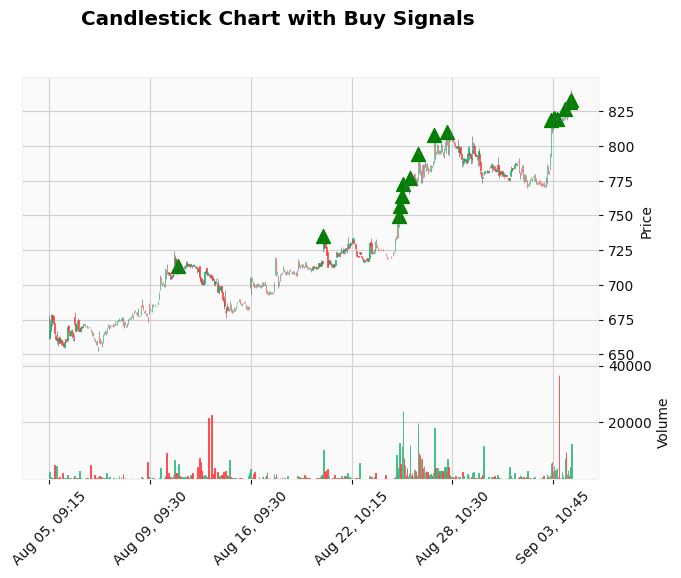

In [95]:
mpf.plot(data,
         type='candle', 
         addplot = [buy_signal_markers],                      # Candlestick chart # Add the buy signal markers
         volume=True,                  # Include volume in the plot
         style='yahoo',                # Style of the plot (e.g., 'yahoo', 'classic', 'default')
         title='Candlestick Chart with Buy Signals',
         ylabel='Price',
         ylabel_lower='Volume')